In [1]:
# MISSING VALUES 

In [2]:
# EGER BIR KOLONUN BIR COK SATIRI BOS ISE SILMEYI TERCIH ET 

In [3]:
# aşagıda onemlı teorık bılgıler verılmıstır makıne ogrenmesınden once verıye uygulamamız gerek seylerı gosterırı

In [5]:
# ==============================================================================
# 📌 MISSING DATA SUMMARY TABLE (EKSİK VERİ ÖZET TABLOSU)
# ==============================================================================
#
# Bu tablo, veri setindeki eksik verilerin (NaN) türlerini, mantığını ve 
# veri biliminde/istatistikte en doğru çözüm yollarını özetler.
#
# ------------------------------------------------------------------------------
# | Type of Missing Data  | Example                            | Best Handling Methods
# ------------------------------------------------------------------------------
# | 1. MCAR               | Ankette yaşın unutulması           | Satırları silmek (dropna) veya
# | (Completely at Random)| veya boş geçilmesi                 | basit ortalama/medyan doldurması.
# # ------------------------------------------------------------------------------
# | 2. MAR                | Eğitim seviyesine bağlı olarak     | Regresyon, KNN Imputer veya
# | (At Random)           | maaş bilgisinin boş kalması        | ilişkili özelliklerle doldurma.
# ------------------------------------------------------------------------------
# | 3. MNAR               | Çok kazananların/Zenginlerin       | Domain Knowledge (Sektör bilgisi)
# | (Not at Random)       | maaşını ankete yazmaması           | veya Missing Indicator ekleme.
# ------------------------------------------------------------------------------
#
# 💡 KISA NOTLAR:
# - MCAR: Tamamen şans eseri eksikliktir, veride yanlılık (bias) yaratmaz.
# - MAR : Eksiklik başka bir değişkene bağlıdır (örn: Erkeklerin kilo yazmaması).
# - MNAR: Eksiklik değişkenin kendi değerine bağlıdır. En tehlikeli ve yanlılık yaratan türdür.
# ==============================================================================
# MCAR = Missing Completely at Random
# MAR = Missing Completely at Random
# MNAR = Missing Not at Random

In [7]:
import  seaborn as sns
import  pandas as pd

In [8]:
df = sns.load_dataset("titanic")

In [9]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [10]:
df.isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [11]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [12]:
df["deck"].unique()

[NaN, 'C', 'E', 'G', 'D', 'A', 'B', 'F']
Categories (7, object): ['A', 'B', 'C', 'D', 'E', 'F', 'G']

In [13]:
df.shape

(891, 15)

In [15]:
df.dropna() # inplace true yapmaddık 

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


In [18]:
df.dropna(axis=1) # eksik verı bulunan kolanları sıldık ama bunu yapmak cok dogrı degıl cunlu age de 177 ksık var deck te 688 tane var
# embarda 2 tane eksık var bunu cok kolay bır sekılde verıyı kayırmayacak bır sekılde doldurabılırız dırekt sılmek yanlıstır

,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alive,alone
0,0,3,male,1,0,7.2500,Third,man,True,no,False
1,1,1,female,1,0,71.2833,First,woman,False,yes,False
2,1,3,female,0,0,7.9250,Third,woman,False,yes,True
3,1,1,female,1,0,53.1000,First,woman,False,yes,False
4,0,3,male,0,0,8.0500,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,0,0,13.0000,Second,man,True,no,True
887,1,1,female,0,0,30.0000,First,woman,False,yes,True
888,0,3,female,1,2,23.4500,Third,woman,False,no,False
889,1,1,male,0,0,30.0000,First,man,True,yes,True


In [19]:
#İMPUTATİON

In [20]:
# mean imputation

<Axes: xlabel='age', ylabel='Count'>

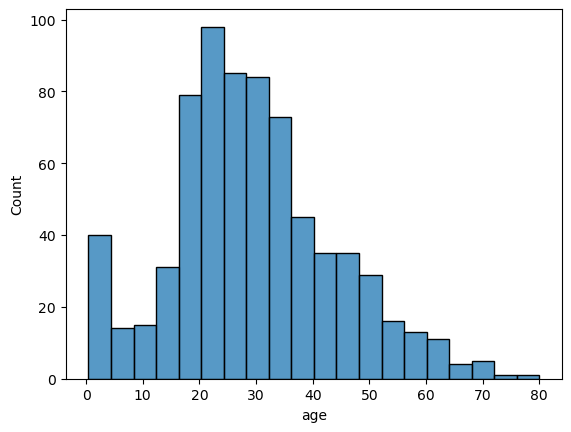

In [22]:
sns.histplot(data =df["age"])

<Axes: xlabel='age', ylabel='Count'>

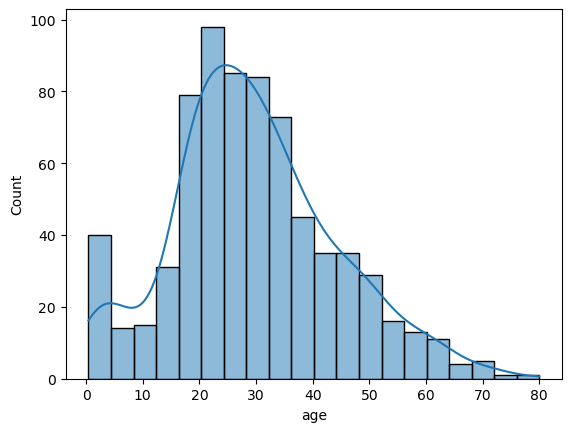

In [23]:
sns.histplot(data=df["age"],kde=True)

In [25]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [28]:
df["age_mean"] = df["age"].fillna(df["age"].mean())

In [30]:
df[["age_mean","age"]] # eksık verı yerıne 29.69 olarak tablouzuu guncelledık 

,age_mean,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


In [31]:
# medyana gorede doldurma yapabılırız 

<Axes: ylabel='age'>

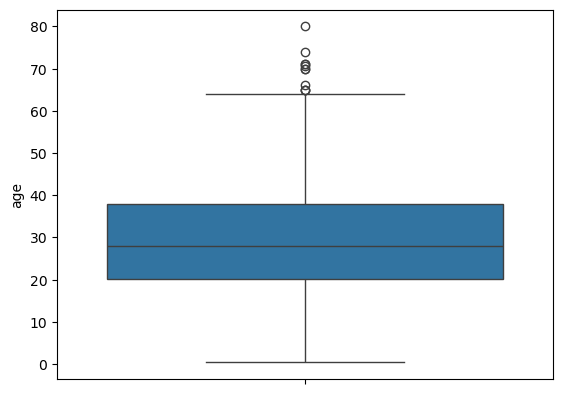

In [32]:
sns.boxplot( data = df , y = "age")

In [33]:
# cok fazla aykırı deger varsa tercıh edebılırız 

In [34]:
df["age median"] = df["age"].fillna(df["age"].median())

In [35]:
df[["age median","age"]]

,age median,age
0,22.0,22.0
1,38.0,38.0
2,26.0,26.0
3,35.0,35.0
4,35.0,35.0
...,...,...
886,27.0,27.0
887,19.0,19.0
888,28.0,NaN
889,26.0,26.0


In [36]:
# kategorık degerlerde genelde mod ıle doldurmayı tercıh ederız 

In [37]:
df[df["embarked"].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_mean,age median
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0


In [38]:
df["embarked"].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [39]:
# embarted kolonumuzun modunu bulalım

In [41]:
mode_value = df[df["embarked"].notna()]["embarked"].mode()[0]

In [42]:
mode_value 

'S'

In [45]:
df["new embarked"] = df["embarked"].fillna(mode_value)

In [46]:
df[["new embarked","embarked"]]

,new embarked,embarked
0,S,S
1,C,C
2,S,S
3,S,S
4,S,S
...,...,...
886,S,S
887,S,S
888,S,S
889,C,C
